# Pathway analysis

In [1]:
import scanpy as sc
import decoupler as dc

# Only needed for processing
import numpy as np
import pandas as pd
from convert_ensembl_2_symbol import *
from plot_GSEA_ORA import *

In [2]:
comparison = 'age'
experiment = "feature_importance_ridge_smote_7b"


In [3]:
# Ger elbow genes
selected_genes_df = pd.read_csv("../data/feature_importance_smote_ridge_7b_top_genes_elbow.csv", index_col= 0)


In [4]:
dds = pd.read_csv(f'/home/amore/work/data/feature_importance_ridge_smote_7b.csv',index_col=0)
dds

,Importance
Feature,
ENSG00000000003.14,0.121967
ENSG00000000005.5,0.054519
ENSG00000000419.12,0.084876
ENSG00000000457.13,0.042627
ENSG00000000460.16,0.002908
...,...
ENSG00000285480.1,0.035708
ENSG00000285491.1,0.063308
ENSG00000285505.1,0.060353


In [6]:
ensembl = list(dds.index)
ensembl_symbol = filter_nameless_genes(ensembl)
symbol = convert_to_symbol(ensembl_symbol)
dds=dds.loc[dds.index.isin(ensembl_symbol)]
dds

,Importance
Feature,
ENSG00000000003.14,0.121967
ENSG00000000005.5,0.054519
ENSG00000000419.12,0.084876
ENSG00000000457.13,0.042627
ENSG00000000460.16,0.002908
...,...
ENSG00000285480.1,0.035708
ENSG00000285491.1,0.063308
ENSG00000285505.1,0.060353


In [7]:
results_df =dds

In [8]:
results_df

,Importance
Feature,
ENSG00000000003.14,0.121967
ENSG00000000005.5,0.054519
ENSG00000000419.12,0.084876
ENSG00000000457.13,0.042627
ENSG00000000460.16,0.002908
...,...
ENSG00000285480.1,0.035708
ENSG00000285491.1,0.063308
ENSG00000285505.1,0.060353


In [ ]:
results_df.to_csv('/home/amore/work/data/feature_importance_ridge_smote_7b_SYMBOLS.csv')

## Get msigdb

In [10]:
msigdb = pd.read_csv('msigdb.csv')

In [ ]:
#msigdb = dc.get_resource('MSigDB')
#msigdb# Sort the results by the ranking metric (e.g., log2 fold change)


In [11]:
# Filter by hallmark
#msigdb = msigdb[msigdb['collection']=='hallmark']

# Remove duplicated entries
msigdb = msigdb[~msigdb.duplicated(['geneset', 'genesymbol'])]

# Rename
#msigdb.loc[:, 'geneset'] = [name.split('HALLMARK_')[1] for name in msigdb['geneset']]

msigdb

,Unnamed: 0,genesymbol,collection,geneset
0,0,MAFF,chemical_and_genetic_perturbations,BOYAULT_LIVER_CANCER_SUBCLASS_G56_DN
1,1,MAFF,chemical_and_genetic_perturbations,ELVIDGE_HYPOXIA_UP
2,2,MAFF,chemical_and_genetic_perturbations,NUYTTEN_NIPP1_TARGETS_DN
3,3,MAFF,immunesigdb,GSE17721_POLYIC_VS_GARDIQUIMOD_4H_BMDC_DN
4,4,MAFF,chemical_and_genetic_perturbations,SCHAEFFER_PROSTATE_DEVELOPMENT_12HR_UP
...,...,...,...,...
3825623,3838543,PRAMEF22,go_biological_process,GOBP_POSITIVE_REGULATION_OF_CELL_POPULATION_PR...
3825624,3838544,PRAMEF22,go_biological_process,GOBP_APOPTOTIC_PROCESS
3825625,3838545,PRAMEF22,go_biological_process,GOBP_REGULATION_OF_CELL_DEATH
3825626,3838546,PRAMEF22,go_biological_process,GOBP_NEGATIVE_REGULATION_OF_DEVELOPMENTAL_PROCESS


In [12]:
set(msigdb["collection"])

{'biocarta_pathways',
 'cancer_gene_neighborhoods',
 'cancer_modules',
 'cell_type_signatures',
 'chemical_and_genetic_perturbations',
 'go_biological_process',
 'go_cellular_component',
 'go_molecular_function',
 'hallmark',
 'human_phenotype_ontology',
 'immunesigdb',
 'kegg_pathways',
 'mirna_targets_legacy',
 'mirna_targets_mirdb',
 'oncogenic_signatures',
 'pid_pathways',
 'positional',
 'reactome_pathways',
 'tf_targets_gtrf',
 'tf_targets_legacy',
 'vaccine_response',
 'wikipathways'}

## GSEA

In [15]:
# Prepare the ranking for GSEA
ranked_genes = results_df[['Importance']].sort_values(by='Importance', ascending=False)

# Prepare the ranking for GSEA
gene_list = ranked_genes['Importance']
gene_list.index = results_df.index  # Ensure the gene symbols are in the index
pd.DataFrame(gene_list)

,Importance
TSPAN6,6.835912
TNMD,6.070028
DPM1,5.917629
SCYL3,5.451860
FIRRM,5.309112
...,...
H2BK1,-4.066075
OR1Q1BP,-4.352626
NaN,-4.736913
NaN,-4.999977


In [29]:
gene_list = gene_list[gene_list.index.notnull()]
gene_list = pd.DataFrame(gene_list)
gene_list

,Importance
TSPAN6,6.835912
TNMD,6.070028
DPM1,5.917629
SCYL3,5.451860
FIRRM,5.309112
...,...
TUSC2P1,-3.109781
OR4M2-OT1,-3.838774
H2BK1,-4.066075
OR1Q1BP,-4.352626


In [26]:
mitocarta_data = pd.read_csv('../data/mitoCarta_terms_tissues_only.csv')
mitocarta_data['collection'] = 'mitocarta'
mitocarta_subset = mitocarta_data[['Symbol', 'collection']]
mitocarta_subset

,Symbol,collection
0,CYC1,mitocarta
1,SDHB,mitocarta
2,COQ7,mitocarta
3,SDHA,mitocarta
4,UQCRC1,mitocarta
...,...,...
1131,NAT8L,mitocarta
1132,MCCD1,mitocarta
1133,PIGBOS1,mitocarta
1134,HTD2,mitocarta


In [27]:
msigdb_extended = pd.concat([msigdb, mitocarta_subset], ignore_index=True)
msigdb_extended = msigdb_extended[~msigdb_extended.duplicated(['geneset', 'genesymbol'])]


{False, True}

In [38]:

# Run GSEA
enr_gsea = dc.get_gsea_df(
    df=gene_list,
    stat="Importance",
    net=msigdb,
    source='geneset',
    target='genesymbol'
)

# Display the top enrichment results
enr_gsea.head()

,Term,ES,NES,NOM p-value,FDR p-value,Set size,Tag %,Rank %,Leading edge
0,AAACCAC_MIR140,0.530314,1.970798,0.014925,0.057771,105,0.571429,0.229588,IGFBP5;GALNT16;COL23A1;OSTM1;TBX3;ACTN4;ATOSA;...
1,AAAGACA_MIR511,0.549461,2.106335,0.001075,0.010759,191,0.643979,0.283599,BTG1;MTAP;SATB2;SLC6A6;RPS6KB1;LUC7L3;SLC22A17...
2,AAAGGAT_MIR501,0.508292,1.906241,0.019814,0.067690,120,0.791667,0.380293,LPIN1;PHF6;SATB2;ZMYM5;MCU;LEPROTL1;SNAP29;NEX...
3,AAAGGGA_MIR204_MIR211,0.466910,1.790710,0.009740,0.045693,212,0.636792,0.317923,CREB5;KHDRBS3;SATB2;SSRP1;ARGLU1;SLTM;KITLG;FH...
4,AAANWWTGC_UNKNOWN,0.461102,1.744932,0.022297,0.072179,179,0.675978,0.333345,DNAJB5;PARP9;SATB2;ASPA;LUC7L3;MRPL24;PIK3R3;A...


In [39]:
enr_gsea.to_csv(f'/home/amore/work/data/{experiment}_{comparison}_GSEA.csv', header=True)

In [3]:
enr_gsea=pd.read_csv(f'/home/amore/work/data/{experiment}_{comparison}_GSEA.csv', index_col=0)
enr_gsea

,Term,ES,NES,NOM p-value,FDR p-value,Set size,Tag %,Rank %,Leading edge
0,AAACCAC_MIR140,0.530314,1.970798,0.014925,0.057771,105,0.571429,0.229588,IGFBP5;GALNT16;COL23A1;OSTM1;TBX3;ACTN4;ATOSA;...
1,AAAGACA_MIR511,0.549461,2.106335,0.001075,0.010759,191,0.643979,0.283599,BTG1;MTAP;SATB2;SLC6A6;RPS6KB1;LUC7L3;SLC22A17...
2,AAAGGAT_MIR501,0.508292,1.906241,0.019814,0.067690,120,0.791667,0.380293,LPIN1;PHF6;SATB2;ZMYM5;MCU;LEPROTL1;SNAP29;NEX...
3,AAAGGGA_MIR204_MIR211,0.466910,1.790710,0.009740,0.045693,212,0.636792,0.317923,CREB5;KHDRBS3;SATB2;SSRP1;ARGLU1;SLTM;KITLG;FH...
4,AAANWWTGC_UNKNOWN,0.461101,1.744932,0.022297,0.072179,179,0.675978,0.333345,DNAJB5;PARP9;SATB2;ASPA;LUC7L3;MRPL24;PIK3R3;A...
...,...,...,...,...,...,...,...,...,...
33031,chrXq26,0.208799,0.730200,0.715777,0.718933,66,0.636364,0.421475,PHF6;ARHGEF6;GPR101;RAP2C;ADGRG4;HS6ST2;PABIR2...
33032,chrXq27,0.230419,0.694463,0.768340,0.770743,23,0.826087,0.581937,FGF13;SPANXC;SOX3;SPANXD;MAGEC1;SPANXN1;ATP11C...
33033,chrXq28,0.398473,1.409540,0.134483,0.180052,107,0.233645,0.087448,TKTL1;ARHGAP4;ATP6AP1;TAFAZZIN;GABRA3;MTMR1;OP...
33034,chrYp11,0.534093,1.476179,0.127438,0.174409,15,0.333333,0.069774,PCDH11Y;PRKY;TBL1Y;ZFY;AMELY


In [4]:
significant_GSEA = enr_gsea[enr_gsea["FDR p-value"] < 0.1].sort_values(by="NES")
significant_GSEA

,Term,ES,NES,NOM p-value,FDR p-value,Set size,Tag %,Rank %,Leading edge
32902,chr2q36,-0.707373,-2.942713,0.000000,0.000000,39,0.230769,0.004913,CCDC195;SCYGR7;SCYGR3;SCYGR6;SCYGR2;SCYGR1;SCY...
12641,GOMF_STRUCTURAL_CONSTITUENT_OF_CHROMATIN,-0.671649,-2.618307,0.012346,0.051509,53,0.245283,0.024839,H2BC7;H2AC4;H3C11;H2BC17;H2BC14;H2AB1;H2BC9;H4...
11057,GOCC_TRANSCRIPTION_FACTOR_TFIID_COMPLEX,-0.656666,-2.518959,0.019868,0.067776,44,0.272727,0.027978,TAF11L7;TAF11L2;TAF11L13;TAF11L9;TAF11L10;TAF1...
32805,chr15q11,-0.626979,-2.369251,0.033333,0.090529,30,0.400000,0.026101,OR4N4C;GOLGA6L22;WHAMMP3;SNURF;OR4M2;GOLGA6L6;...
11084,GOCC_T_CELL_RECEPTOR_COMPLEX,-0.481253,-2.180335,0.009709,0.045693,138,0.905797,0.397011,TRDD1;TRAV13-2;TRBV11-3;TRBV17;TRDV1;TRBV7-6;T...
...,...,...,...,...,...,...,...,...,...
19077,HP_ABNORMAL_MALE_INTERNAL_GENITALIA_MORPHOLOGY,0.747796,2.699598,0.000000,0.000000,77,0.246753,0.056365,CFTR;GCLC;SRCAP;CDH1;RAD51;CLCA4;KLF6;SLC9A3;S...
18355,HP_ABNORMALITY_OF_BODY_MASS_INDEX,0.854087,2.709432,0.000000,0.000000,28,0.285714,0.032004,CFTR;GCLC;SLC25A13;CLCA4;SLC9A3;SLC11A1;HFE;SL...
22809,HP_REDUCED_FORCED_EXPIRATORY_VOLUME_IN_ONE_SECOND,0.845079,2.711506,0.000000,0.000000,27,0.222222,0.012761,CFTR;GCLC;CLCA4;SLC11A1;DNAH9;HFE
32989,chr7q21,0.827723,2.931912,0.000000,0.000000,77,0.285714,0.043229,CALCR;ABCB4;ANKIB1;ASNS;SLC25A13;PDK4;CYP51A1;...


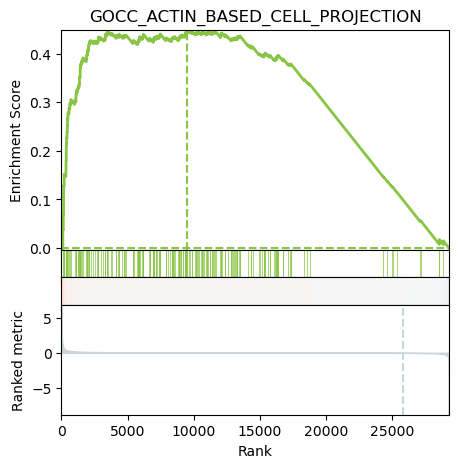

In [44]:
# Plot
dc.plot_running_score(
    df=gene_list,
    stat='Importance',
    net=msigdb[msigdb['collection']=='go_cellular_component'],
    source='geneset',
    target='genesymbol',
    set_name='GOCC_ACTIN_BASED_CELL_PROJECTION'
)

In [55]:
gene_list.index

Index(['TSPAN6', 'TNMD', 'DPM1', 'SCYL3', 'FIRRM', 'FGR', 'CFH', 'FUCA2',
       'GCLC', 'NFYA',
       ...
       'OR11J6P', 'PDGFRL2P', 'POLR2J3', 'TUSC2P2', 'C4orf36', 'TUSC2P1',
       'OR4M2-OT1', 'H2BK1', 'OR1Q1BP', 'TBCEL-TECTA'],
      dtype='object', length=29309)

## ORA

In [13]:
selected_genes_df

,coef,abs_coef
Ensembl,,
ENSG00000004848.7,1.272214,1.272214
ENSG00000009307.15,1.614391,1.614391
ENSG00000015479.18,2.187071,2.187071
ENSG00000022267.16,2.043561,2.043561
ENSG00000036448.9,0.849731,0.849731
...,...,...
ENSG00000273079.5,-0.677420,0.677420
ENSG00000278395.1,-0.754326,0.754326
ENSG00000280646.2,-0.815350,0.815350


In [14]:
ensembl = list(selected_genes_df.index)
ensembl_symbol = filter_nameless_genes(ensembl)
symbol = convert_to_symbol(ensembl_symbol)
selected_genes_df["symbol"]=symbol
selected_genes_df.index = symbol
selected_genes_df.head()

,coef,abs_coef,symbol
ARX,1.272214,1.272214,ARX
CSDE1,1.614391,1.614391,CSDE1
MATR3,2.187071,2.187071,MATR3
FHL1,2.043561,2.043561,FHL1
MYOM2,0.849731,0.849731,MYOM2


In [15]:
selected_genes_df= selected_genes_df.dropna()

In [16]:
results_df.to_csv('/home/amore/work/data/feature_importance_ridge_smote_7b_selected_SYMBOLS.csv')

In [10]:
# Infer enrichment with ora using significant deg
top_genes = list(selected_genes_df["symbol"])

# Run ora
enr_pvals = dc.get_ora_df(
    df=top_genes,
    net=msigdb,
    source='geneset',
    target='genesymbol'
)


enr_pvals.head()

,Term,Set size,Overlap ratio,p-value,FDR p-value,Odds ratio,Combined score,Features
0,AAACCAC_MIR140,110,0.027273,0.262421,0.633366,1.965728,2.629759,ANK2;SLC38A2;SLMAP
1,AAAGACA_MIR511,204,0.019608,0.419314,0.735829,1.363442,1.185017,CALM1;LUC7L3;METAP2;UBE2H
2,AAAGGAT_MIR501,127,0.031496,0.150195,0.513162,2.195360,4.162014,BCL6;KIF1C;SLC25A3;TNNI2
3,AAAGGGA_MIR204_MIR211,224,0.008929,0.879507,0.960040,0.685002,0.087950,ARGLU1;COX5A
4,AAANWWTGC_UNKNOWN,194,0.046392,0.004398,0.057833,3.076034,16.692108,ANK2;BCL6;CALM1;DMD;GRIN2B;LUC7L3;RBMX;SLMAP;T...


In [12]:
experiment

'feature_importance_ridge_smote_7b'

In [13]:
enr_pvals.to_csv(f'/home/amore/work/data/{experiment}_{comparison}_ORA.csv', header=True)

In [14]:
enr_pvals=pd.read_csv(f'/home/amore/work/data/{experiment}_{comparison}_ORA.csv', index_col=0)
enr_pvals

,Term,Set size,Overlap ratio,p-value,FDR p-value,Odds ratio,Combined score,Features
0,AAACCAC_MIR140,110,0.027273,0.262421,0.633366,1.965728,2.629759,ANK2;SLC38A2;SLMAP
1,AAAGACA_MIR511,204,0.019608,0.419314,0.735829,1.363442,1.185017,CALM1;LUC7L3;METAP2;UBE2H
2,AAAGGAT_MIR501,127,0.031496,0.150195,0.513162,2.195360,4.162014,BCL6;KIF1C;SLC25A3;TNNI2
3,AAAGGGA_MIR204_MIR211,224,0.008929,0.879507,0.960040,0.685002,0.087950,ARGLU1;COX5A
4,AAANWWTGC_UNKNOWN,194,0.046392,0.004398,0.057833,3.076034,16.692108,ANK2;BCL6;CALM1;DMD;GRIN2B;LUC7L3;RBMX;SLMAP;T...
...,...,...,...,...,...,...,...,...
19021,chrXq22,89,0.022472,0.422530,0.740040,1.729976,1.490366,RPL36A;TBC1D8B
19022,chrXq25,12,0.083333,0.177524,0.555431,7.437581,12.856964,STAG2
19023,chrXq26,74,0.027027,0.336292,0.709101,2.079858,2.266580,FHL1;RBMX
19024,chrXq28,114,0.008772,0.844551,0.936716,0.807820,0.136482,RPL10


In [15]:
significant_ORA = enr_pvals[(enr_pvals["p-value"] < 0.05) & (enr_pvals["FDR p-value"] < 0.05)]
significant_ORA.sort_values(by="Combined score")

,Term,Set size,Overlap ratio,p-value,FDR p-value,Odds ratio,Combined score,Features
13821,MEF2C_TARGET_GENES,1489,0.025520,3.427497e-03,4.723728e-02,1.675929,9.512450,AKAP13;B2M;CALM1;CAST;CCT2;CD36;EFHC1;EIF4E2;F...
17638,SCGGAAGY_ELK1_02,1236,0.026699,3.203283e-03,4.517652e-02,1.750014,10.051345,ALDOA;ARPC2;ATP2A2;COX6B1;EIF3L;FANCD2;GAPDH;G...
13599,LHX2_TARGET_GENES,1235,0.026721,3.163652e-03,4.479756e-02,1.751524,10.081821,ATP5PF;BCL6;EEF1A1;ENY2;FEZ2;FHL1;HCFC1R1;IST1...
11065,HP_ABNORMAL_JOINT_MORPHOLOGY,1141,0.027169,3.290407e-03,4.606570e-02,1.779258,10.171563,CFL2;DMD;DNAJC21;FANCD2;FHL1;FLNC;GNAS;HBB;HNR...
5498,GOMF_PROTEIN_CONTAINING_COMPLEX_BINDING,1275,0.026667,2.835243e-03,4.093730e-02,1.749538,10.262141,ANK2;ARPC2;B2M;BLOC1S6;CAMSAP2;CD36;CFL2;CRYAB...
...,...,...,...,...,...,...,...,...
16139,MORF_TPT1,102,0.352941,7.947279e-39,8.400274e-36,24.646286,2162.169137,B2M;BTF3;EEF1A1;EEF2;FAU;MYL6;NACA;OAZ1;PCBP2;...
15983,MORF_ACTG1,138,0.311594,1.492183e-43,5.678054e-40,22.240294,2193.135852,ARPC2;B2M;BTF3;COX4I1;EEF1A1;EEF2;FAU;GNAS;MYL...
18341,WP_CYTOPLASMIC_RIBOSOMAL_PROTEINS,88,0.386364,2.574120e-38,2.448761e-35,26.813472,2320.779042,FAU;RPL10;RPL13;RPL13A;RPL14;RPL21;RPL23;RPL26...
13367,KEGG_RIBOSOME,87,0.390805,1.602146e-38,1.604338e-35,27.121273,2360.280046,FAU;RPL10;RPL13;RPL13A;RPL14;RPL21;RPL23;RPL26...


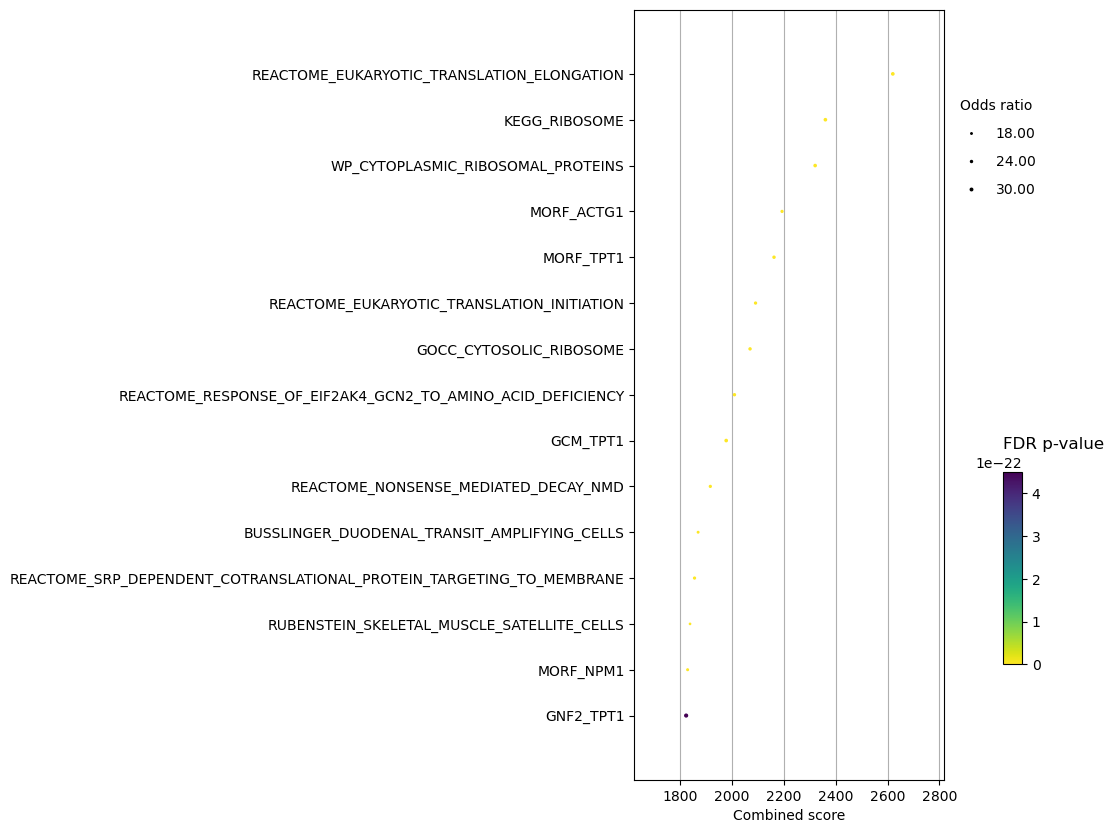

In [16]:
dc.plot_dotplot(
    enr_pvals.sort_values('Combined score', ascending=False).head(15),
    x='Combined score',
    y='Term',
    s='Odds ratio',
    c='FDR p-value',
    scale=0.01,
    figsize=(5, 10)
)

/home/amore/work/notebooks/plot_GSEA_ORA.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ora_top['Term'], fontsize=fontsize_text)


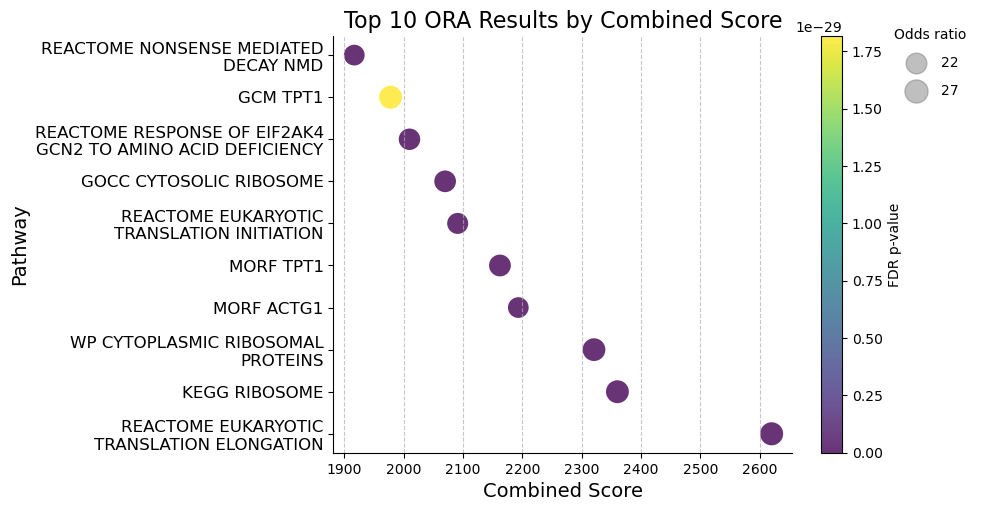

In [19]:
fig, ax = plot_ora_results(ora_df=significant_ORA, top_n=10, figsize=(10, 6), scale_odds_ratio=10, 
                     fontsize_title=16, fontsize_subtitle=14, fontsize_text=12,
                     fdr_bar_size=[0.1, 0.05, 0.303, 0.98])
fig.savefig(f"results/{experiment}_{comparison}_ORA_bubble.png", bbox_inches='tight')


### GSEA vs ORA

In [72]:
common_enrihment = enr_gsea[enr_gsea['Term'].isin(significant_ORA['Term'])].sort_values(by="NES")
common_enrihment

,Term,ES,NES,NOM p-value,FDR p-value,Set size,Tag %,Rank %,Leading edge
2274,GAUTAM_EYE_IRIS_CILIARY_BODY_RIBOSOMAL_GENES_H...,0.451763,1.219986,0.225000,0.255864,14,0.785714,0.415879,PFDN4;CMTM8;ACYP1;CETN2;TNNC1;SERF2;DRAM2;SNRP...
21666,HP_LEFT_ANTERIOR_FASCICULAR_BLOCK,0.531673,1.228626,0.246790,0.275564,7,0.857143,0.344092,LMNA;TRPM4;ACTC1;FLNC;TNNC1;TNNI3K
10370,GOCC_CYTOSOLIC_RIBOSOME,0.356548,1.268603,0.219484,0.251164,99,0.545455,0.302535,RPS15A;RPS13;RPL7;RPL24;RPS8;RPLP0;RPS25;RPL10...
29195,REACTOME_EUKARYOTIC_TRANSLATION_ELONGATION,0.368602,1.314621,0.194412,0.229879,93,0.752688,0.446620,RPS15A;RPS13;RPL7;RPS21;RPL24;RPS8;RPLP0;RPL4;...
29917,REACTOME_RESPONSE_OF_EIF2AK4_GCN2_TO_AMINO_ACI...,0.382693,1.373308,0.167436,0.207201,100,0.780000,0.449282,RPS15A;RPS13;CEBPG;TRIB3;RPL7;EIF2S1;RPS21;GCN...
24045,KEGG_RIBOSOME,0.389633,1.382646,0.167251,0.207065,86,0.755814,0.446620,RPS15A;RPS13;RPL7;RPS21;RPL24;RPS8;RPLP0;RPL4;...
29641,REACTOME_NONSENSE_MEDIATED_DECAY_NMD,0.395766,1.428849,0.152348,0.194805,115,0.556522,0.307278,RPS15A;RPS13;RPL7;RPL24;NCBP2;RPS8;RPLP0;SMG9;...
21667,HP_LEFT_BUNDLE_BRANCH_BLOCK,0.499010,1.435904,0.130607,0.176949,17,1.000000,0.501279,MYL2;PRKAG2;CTNNA3;LMNA;TRPM4;CDH2;DSG2;ACTC1;...
31696,WP_CYTOPLASMIC_RIBOSOMAL_PROTEINS,0.406488,1.450003,0.135831,0.181178,87,0.586207,0.302535,RPS15A;RPS6KB1;RPS13;RPS6KA1;RPL7;RPL24;RPS8;R...
24133,KOBAYASHI_EGFR_SIGNALING_24HR_UP,0.400810,1.451584,0.126949,0.173984,97,0.350515,0.164079,SYNE2;PIK3R3;ST6GALNAC2;HCFC1R1;CBLB;CD74;ABHD...


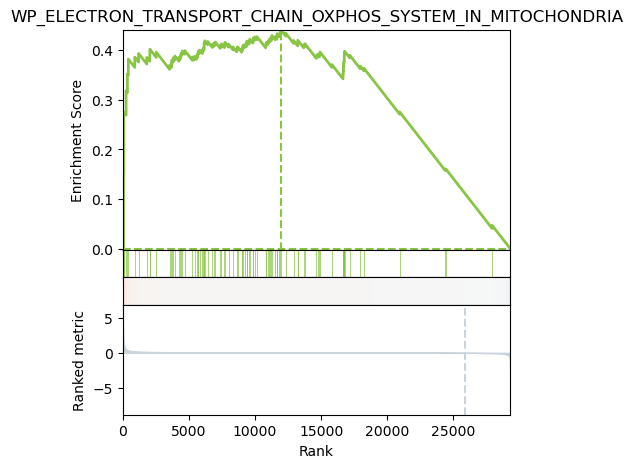

In [78]:
# Plot
dc.plot_running_score(
    df=gene_list,
    stat='Importance',
    net=msigdb[msigdb['collection']=='wikipathways'],
    source='geneset',
    target='genesymbol',
    set_name='WP_ELECTRON_TRANSPORT_CHAIN_OXPHOS_SYSTEM_IN_MITOCHONDRIA'
)

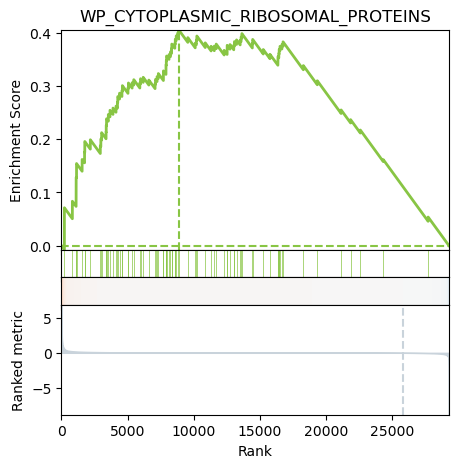

In [79]:

# Plot
dc.plot_running_score(
    df=gene_list,
    stat='Importance',
    net=msigdb[msigdb['collection']=='wikipathways'],
    source='geneset',
    target='genesymbol',
    set_name='WP_CYTOPLASMIC_RIBOSOMAL_PROTEINS'
)

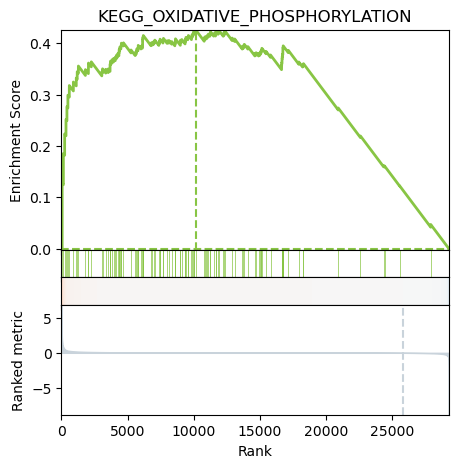

In [80]:
# Plot
dc.plot_running_score(
    df=gene_list,
    stat='Importance',
    net=msigdb[msigdb['collection']=='kegg_pathways'],
    source='geneset',
    target='genesymbol',
    set_name='KEGG_OXIDATIVE_PHOSPHORYLATION'
)

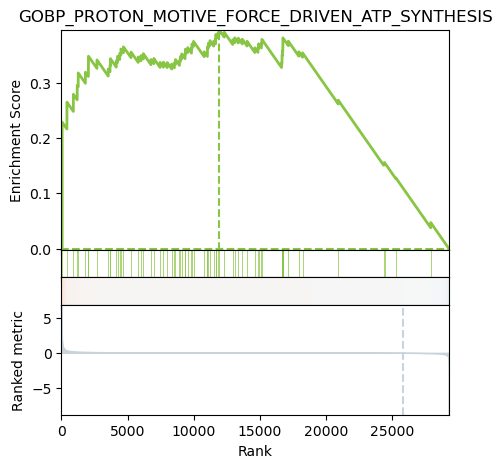

In [81]:
# Plot
dc.plot_running_score(
    df=gene_list,
    stat='Importance',
    net=msigdb[msigdb['collection']=='go_biological_process'],
    source='geneset',
    target='genesymbol',
    set_name='GOBP_PROTON_MOTIVE_FORCE_DRIVEN_ATP_SYNTHESIS'
)

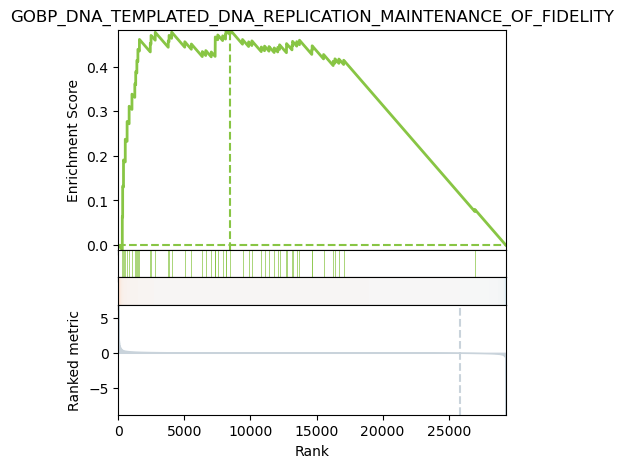

In [82]:
# Plot
dc.plot_running_score(
    df=gene_list,
    stat='Importance',
    net=msigdb[msigdb['collection']=='go_biological_process'],
    source='geneset',
    target='genesymbol',
    set_name='GOBP_DNA_TEMPLATED_DNA_REPLICATION_MAINTENANCE_OF_FIDELITY'
)



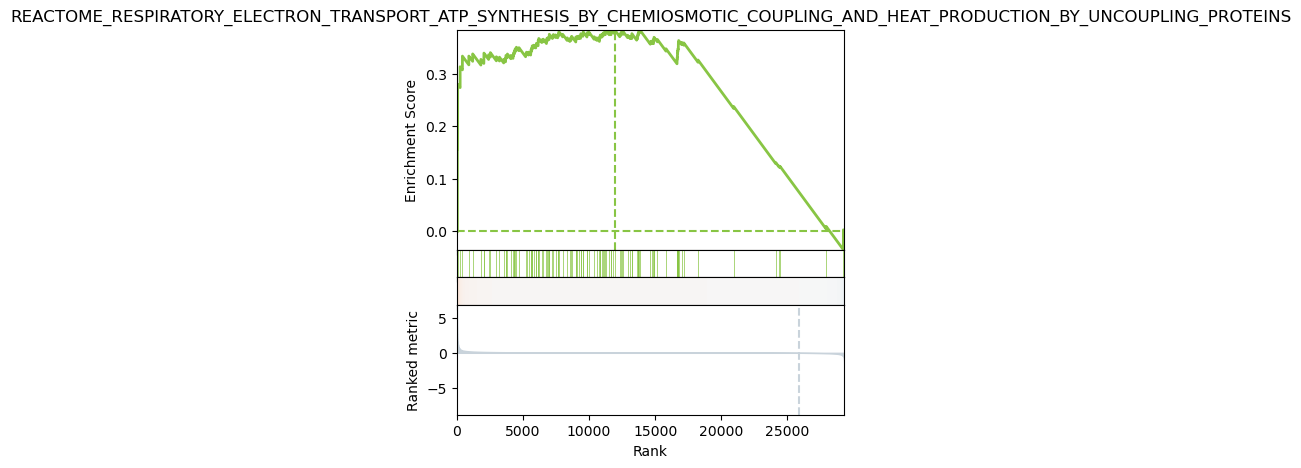

In [83]:
# Plot
dc.plot_running_score(
    df=gene_list,
    stat='Importance',
    net=msigdb[msigdb['collection']=='reactome_pathways'],
    source='geneset',
    target='genesymbol',
    set_name='REACTOME_RESPIRATORY_ELECTRON_TRANSPORT_ATP_SYNTHESIS_BY_CHEMIOSMOTIC_COUPLING_AND_HEAT_PRODUCTION_BY_UNCOUPLING_PROTEINS'
)



In [73]:
set(msigdb["collection"])

{'biocarta_pathways',
 'cancer_gene_neighborhoods',
 'cancer_modules',
 'cell_type_signatures',
 'chemical_and_genetic_perturbations',
 'go_biological_process',
 'go_cellular_component',
 'go_molecular_function',
 'hallmark',
 'human_phenotype_ontology',
 'immunesigdb',
 'kegg_pathways',
 'mirna_targets_legacy',
 'mirna_targets_mirdb',
 'oncogenic_signatures',
 'pid_pathways',
 'positional',
 'reactome_pathways',
 'tf_targets_gtrf',
 'tf_targets_legacy',
 'vaccine_response',
 'wikipathways'}